the important library that we used in project
--------------

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Load Data & Generate Summary Statistics
----------------

In [4]:
df=pd.read_csv("hotel_bookings.csv")

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.shape

(119390, 32)

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

------------------------------

After I saw the data, my report about it:
The dataset contains several issues. For example, there are missing values in some columns, inconsistent date formats, and potential outliers that may affect the analysis. These problems could lead to inaccurate insights and unreliable results.

so,Based on these observations, I will perform data cleaning steps such as handling missing values, removing duplicates, treating outliers, converting data types, and preparing the dataset for further analysis.

.......................

Identify Missing Values

In [14]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

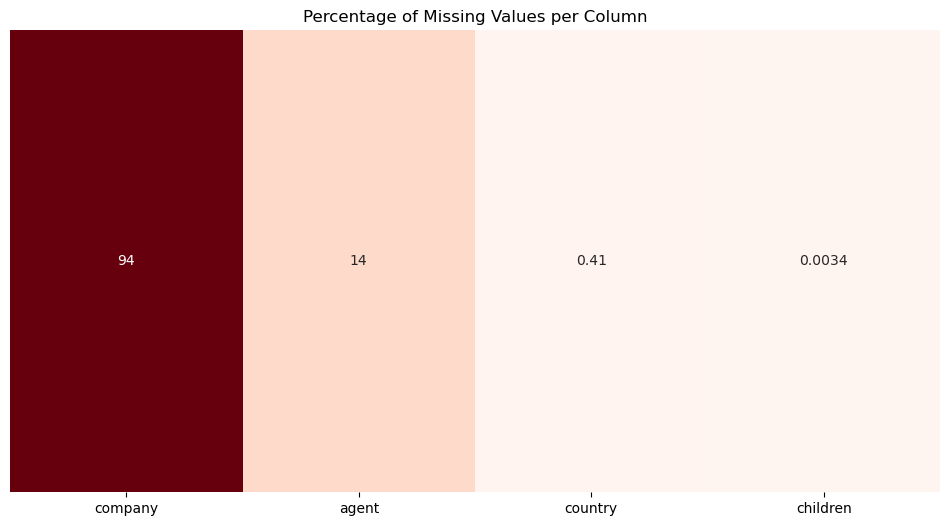

In [15]:
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(12,6))
sns.heatmap(missing_percent.to_frame().T, annot=True, cmap="Reds", cbar=False)
plt.title("Percentage of Missing Values per Column")
plt.yticks([])
plt.show()

...................

Detect Outliers and plot it

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_summary[col] = len(outliers)

outlier_summary = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier_Count'])
print(outlier_summary)

                                Outlier_Count
is_canceled                                 0
lead_time                                3005
arrival_date_year                           0
arrival_date_week_number                    0
arrival_date_day_of_month                   0
stays_in_weekend_nights                   265
stays_in_week_nights                     3354
adults                                  29710
children                                 8590
babies                                    917
is_repeated_guest                        3810
previous_cancellations                   6484
previous_bookings_not_canceled           3620
booking_changes                         18076
agent                                       0
company                                     0
days_in_waiting_list                     3698
adr                                      3793
required_car_parking_spaces              7416
total_of_special_requests                2877


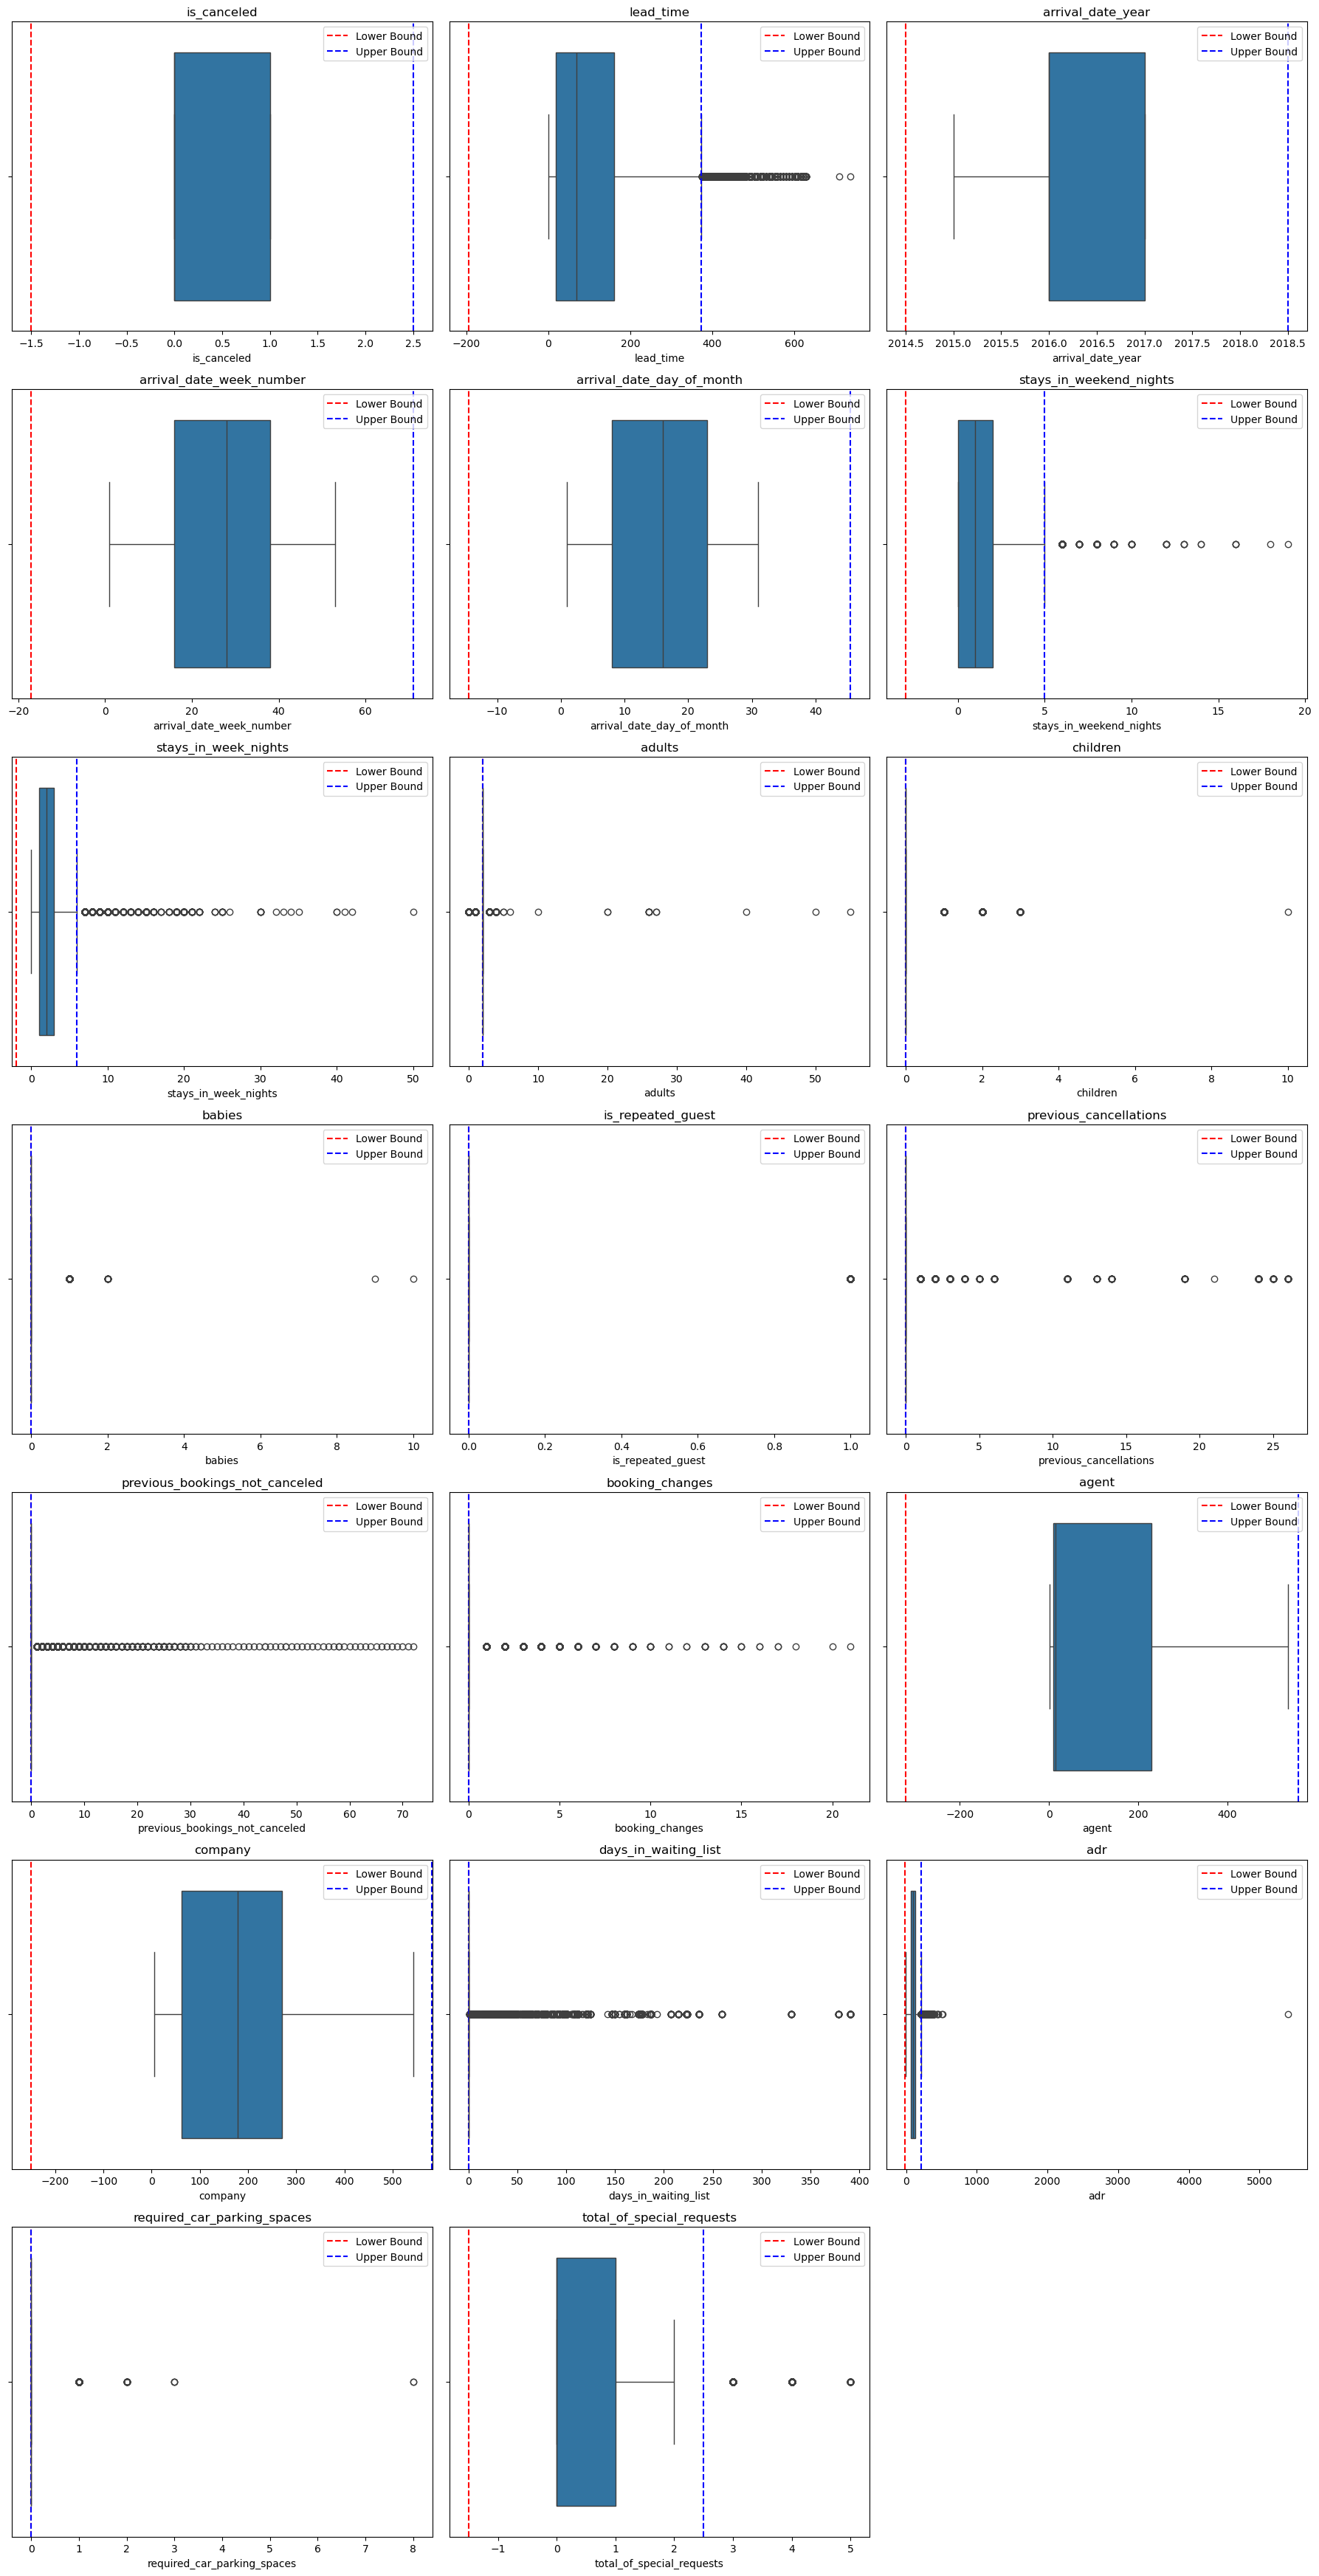

In [19]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.axvline(lower, color='red', linestyle='--', label='Lower Bound')
    plt.axvline(upper, color='blue', linestyle='--', label='Upper Bound')
    plt.title(f"{col}")
    plt.legend()

plt.tight_layout()
plt.show()

.......................

Data Cleaning
-------------------

Handle Missing Values

In [22]:
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

df["country"] = df["country"].fillna(df["country"].mode()[0])

df["children"] = df["children"].fillna(df["children"].median())

In [23]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

........................

Remove Duplicates

In [26]:
df = df.drop_duplicates()

................

Handle Outliers

##First, we make sure that the outlayer needs to be removed or not, because we may later use this outlook to target a specific thing.

In [30]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
impact_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_mask = (df[col] < lower) | (df[col] > upper)
    non_outliers_mask = ~outliers_mask

    if outliers_mask.sum() > 0:
        cancel_rate_outliers = df.loc[outliers_mask, "is_canceled"].mean()
        cancel_rate_non_outliers = df.loc[non_outliers_mask, "is_canceled"].mean()
        diff = abs(cancel_rate_outliers - cancel_rate_non_outliers)

        impact_summary.append({
            "Column": col,
            "Outlier_Count": outliers_mask.sum(),
            "Cancel_Rate_Outliers": cancel_rate_outliers,
            "Cancel_Rate_Non_Outliers": cancel_rate_non_outliers,
            "Difference": diff
        })

impact_summary = pd.DataFrame(impact_summary).sort_values("Difference", ascending=False)
display(impact_summary)

,Column,Outlier_Count,Cancel_Rate_Outliers,Cancel_Rate_Non_Outliers,Difference
7,previous_cancellations,1685,0.678932,0.267003,0.411929
13,required_car_parking_spaces,7313,0.000000,0.300060,0.300060
8,previous_bookings_not_canceled,3545,0.049929,0.284462,0.234532
1,stays_in_weekend_nights,220,0.504545,0.274367,0.230179
6,is_repeated_guest,3415,0.076428,0.283021,0.206593
0,lead_time,2396,0.460351,0.269719,0.190631
10,company,5255,0.109229,0.285551,0.176321
9,booking_changes,15901,0.154519,0.301738,0.147219
14,total_of_special_requests,2672,0.162051,0.278508,0.116457
12,adr,2488,0.387862,0.271637,0.116225


...............

##after ensure handle the noise outlayer

In [33]:
low_impact_cols = ["babies", "children", "stays_in_week_nights", "days_in_waiting_list", "adults"]

for col in low_impact_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df.loc[df[col] < lower, col] = lower
    df.loc[df[col] > upper, col] = upper

C:\Users\ELOott\AppData\Local\Temp\ipykernel_404\853573007.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < lower, col] = lower


...................

Fix Data Types

In [36]:
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], errors="coerce")
df["day"] = df["reservation_status_date"].dt.day
df["month"] = df["reservation_status_date"].dt.month
df["year"] = df["reservation_status_date"].dt.year

decrease the memory size

In [38]:
df = df.copy()
for col in df.select_dtypes(include=["int64"]).columns:
    df.loc[:, col] = df[col].astype("int32")

for col in df.select_dtypes(include=["float64"]).columns:
    df.loc[:, col] = df[col].astype("float32")

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87377 entries, 0 to 119389
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87377 non-null  object        
 1   is_canceled                     87377 non-null  int64         
 2   lead_time                       87377 non-null  int64         
 3   arrival_date_year               87377 non-null  int64         
 4   arrival_date_month              87377 non-null  object        
 5   arrival_date_week_number        87377 non-null  int64         
 6   arrival_date_day_of_month       87377 non-null  int64         
 7   stays_in_weekend_nights         87377 non-null  int64         
 8   stays_in_week_nights            87377 non-null  float64       
 9   adults                          87377 non-null  int64         
 10  children                        87377 non-null  float64       
 11  babies

..................................

Feature Engineering &Visualization & Preprocessing & Split
----------------

Create New Features

In [42]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["is_family"] = ((df["children"] + df["babies"]) > 0).astype(int)

In [43]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,day,month,year,total_guests,total_nights,is_family
119385,City Hotel,0,23,2017,August,35,30,2,5.0,2,...,0,0,Check-Out,2017-09-06,6,9,2017,2.0,7.0,0
119386,City Hotel,0,102,2017,August,35,31,2,5.0,2,...,0,2,Check-Out,2017-09-07,7,9,2017,2.0,7.0,0
119387,City Hotel,0,34,2017,August,35,31,2,5.0,2,...,0,4,Check-Out,2017-09-07,7,9,2017,2.0,7.0,0
119388,City Hotel,0,109,2017,August,35,31,2,5.0,2,...,0,0,Check-Out,2017-09-07,7,9,2017,2.0,7.0,0
119389,City Hotel,0,205,2017,August,35,29,2,7.0,2,...,0,2,Check-Out,2017-09-07,7,9,2017,2.0,9.0,0


.........................

visualization to important relation in data
------------

Cancellation Rate by Hotel Type

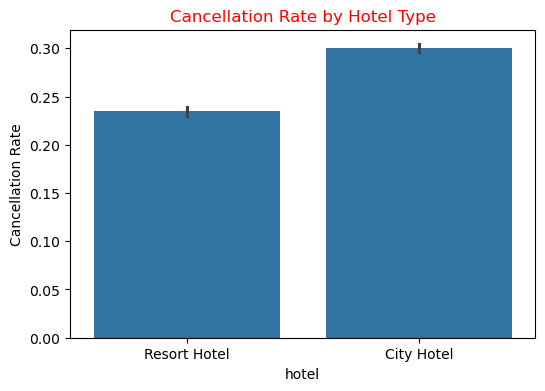

In [47]:
plt.figure(figsize=(6,4))
sns.barplot(x="hotel", y="is_canceled", data=df, estimator=lambda x: sum(x)/len(x))
plt.title("Cancellation Rate by Hotel Type",color="red")
plt.ylabel("Cancellation Rate")
# plt.savefig("Cancellation Rate by Hotel Type.png")
plt.show()

Cancellations by Month

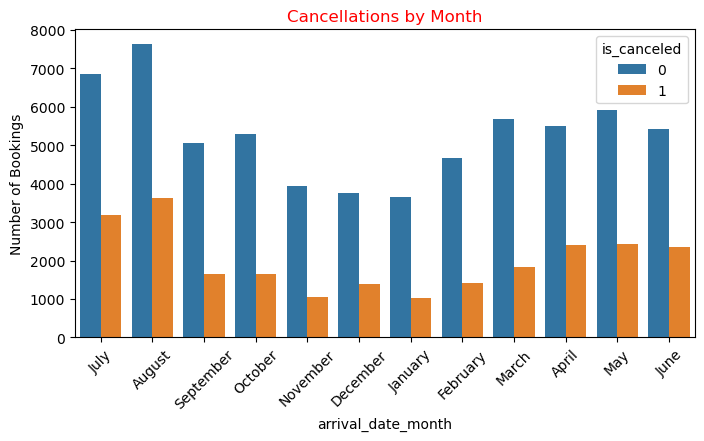

In [49]:
plt.figure(figsize=(8,4))
sns.countplot(x="arrival_date_month", hue="is_canceled", data=df, order=df['arrival_date_month'].unique())
plt.title("Cancellations by Month",color="red")
plt.xticks(rotation=45)
plt.ylabel("Number of Bookings")
# plt.savefig("Cancellations by Month.png")
plt.show()

Average Daily Rate by Market Segment

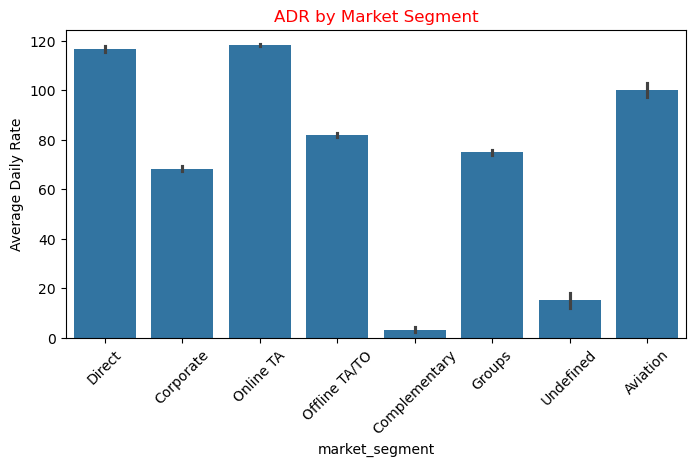

In [51]:
plt.figure(figsize=(8,4))
sns.barplot(x="market_segment", y="adr", data=df)
plt.title("ADR by Market Segment",color="red")
plt.xticks(rotation=45)
plt.ylabel("Average Daily Rate")
# plt.savefig("ADR by Market Segment.png")
plt.show()

Country Distribution of Bookings

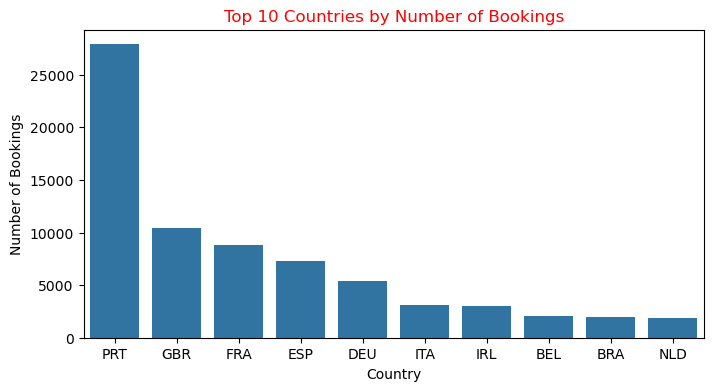

In [53]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries by Number of Bookings",color="red")
plt.ylabel("Number of Bookings")
plt.xlabel("Country")
# plt.savefig("Top 10 Countries by Number of Bookings.png")
plt.show()

From the data analysis through visualization:

The Average Daily Rate (ADR) was highest in the "Direct" and "Online TA" segments (over 100), while "Military" and "Undefined" were the lowest (under 20).
The number of bookings was significantly high in "PRT" (close to 25,000), decreasing gradually in other countries.
The cancellation rate was higher in "City Hotel" (around 0.3) compared to "Resort Hotel" (around 0.25).
The number of cancellations was high in July and August (over 6,000), then gradually declined through June.

This might indicate:

A strong focus on direct and online travel agency markets, but a need to improve services in city hotels to reduce cancellations.
A seasonal appeal in "PRT" possibly due to tourism, with lower demand in other markets.
Seasonal impacts on cancellations, with the summer peak possibly reflecting changes in travel plans.

......................

Encode Categorical Variables

In [57]:
low_cardinality = ["meal", "market_segment", "deposit_type", "customer_type", "hotel"]
df = pd.get_dummies(df, columns=low_cardinality, drop_first=True)
high_cardinality = ["country"]

for col in high_cardinality:
    counts = df[col].value_counts()
    df[col] = df[col].where(df[col].isin(counts[counts > 100].index), "Other")

df = pd.get_dummies(df, columns=high_cardinality, drop_first=True)

Remove Data Leakage

In [59]:
df = df.drop(["reservation_status", "reservation_status_date"], axis=1)

In [60]:
df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,country_NLD,country_NOR,country_Other,country_POL,country_PRT,country_ROU,country_RUS,country_SWE,country_TUR,country_USA
0,0,342,2015,July,27,1,0,0.0,2,0.0,...,False,False,False,False,True,False,False,False,False,False
1,0,737,2015,July,27,1,0,0.0,2,0.0,...,False,False,False,False,True,False,False,False,False,False
2,0,7,2015,July,27,1,0,1.0,2,0.0,...,False,False,False,False,False,False,False,False,False,False
3,0,13,2015,July,27,1,0,1.0,2,0.0,...,False,False,False,False,False,False,False,False,False,False
4,0,14,2015,July,27,1,0,2.0,2,0.0,...,False,False,False,False,False,False,False,False,False,False


In [61]:
df.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'distribution_channel', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'reserved_room_type', 'assigned_room_type', 'booking_changes', 'agent',
       'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'day', 'month', 'year', 'total_guests',
       'total_nights', 'is_family', 'meal_FB', 'meal_HB', 'meal_SC',
       'meal_Undefined', 'market_segment_Complementary',
       'market_segment_Corporate', 'market_segment_Direct',
       'market_segment_Groups', 'market_segment_Offline TA/TO',
       'market_segment_Online TA', 'market_segment_Undefined',
       'deposit_type_Non Refund', 'deposit_type_Refundable',
       'customer_type_Group', 'customer_

Final Preparation (Train/Test Split)

In [63]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(69901, 81) (17476, 81) (69901,) (17476,)
